In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

In [3]:
iris = load_iris()
X = iris.data[:,(2,3)]
y = (iris.target==0).astype(int)

In [4]:
per_clf = Perceptron()
per_clf.fit(X,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [5]:
y_pred = per_clf.predict([[2,0.5]])

In [6]:
y_pred

array([0])

In [7]:
import tensorflow as tf
from tensorflow import keras

In [8]:
tf.__version__

'2.21.0'

In [9]:
keras.__version__

'3.13.2'

In [10]:
fashion_mist = keras.datasets.fashion_mnist

In [11]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mist.load_data()

In [12]:
X_train_full.shape

(60000, 28, 28)

In [13]:
X_train_full.dtype

dtype('uint8')

In [14]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [15]:
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [16]:
class_names[y_train[0]]

'Coat'

In [17]:
y_valid

array([9, 0, 0, ..., 5, 8, 3], shape=(5000,), dtype=uint8)

In [18]:
y_train

array([4, 0, 7, ..., 3, 0, 5], shape=(55000,), dtype=uint8)

In [19]:
X_valid.shape

(5000, 28, 28)

In [20]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28])),
model.add(keras.layers.Dense(300,activation="relu")),
model.add(keras.layers.Dense(100,activation="relu")),
model.add(keras.layers.Dense(10,activation="softmax"))

C:\Users\Berkay\Desktop\ML_projects\LSTM_sentiment\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:
hidden1 = model.layers[1]

In [24]:
hidden1.name

'dense'

In [25]:
model.get_layer("dense")

<Dense name=dense, built=True>

In [26]:
weights, biases = hidden1.get_weights()

In [27]:
weights

array([[-0.06370362,  0.02102358,  0.02682393, ..., -0.01841539,
         0.04984245,  0.04773161],
       [-0.03016313, -0.02336322, -0.00213764, ...,  0.04687432,
        -0.00092265,  0.02188621],
       [ 0.04885206,  0.03641886,  0.01642158, ...,  0.02213198,
        -0.06655861,  0.03847305],
       ...,
       [-0.0116038 , -0.0272852 , -0.02811719, ...,  0.03451717,
         0.03875448, -0.06906063],
       [-0.05805232,  0.04241804,  0.05566335, ..., -0.04140636,
         0.04630531, -0.07152709],
       [-0.07271931,  0.00651031,  0.04105861, ...,  0.0382652 ,
        -0.04771043, -0.03039926]], shape=(784, 300), dtype=float32)

In [28]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [29]:
biases.shape

(300,)

In [30]:
model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [31]:
history = model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7635 - loss: 0.7221 - val_accuracy: 0.8342 - val_loss: 0.4961
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8302 - loss: 0.4870 - val_accuracy: 0.8460 - val_loss: 0.4587
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8448 - loss: 0.4402 - val_accuracy: 0.8586 - val_loss: 0.4131
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8549 - loss: 0.4140 - val_accuracy: 0.8622 - val_loss: 0.3992
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8631 - loss: 0.3920 - val_accuracy: 0.8664 - val_loss: 0.3825
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8677 - loss: 0.3756 - val_accuracy: 0.8676 - val_loss: 0.3774
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8705 - loss: 0.3631 - val_accuracy: 0.8736 - val_loss: 0.3686
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8747 - loss: 0.3502 - 

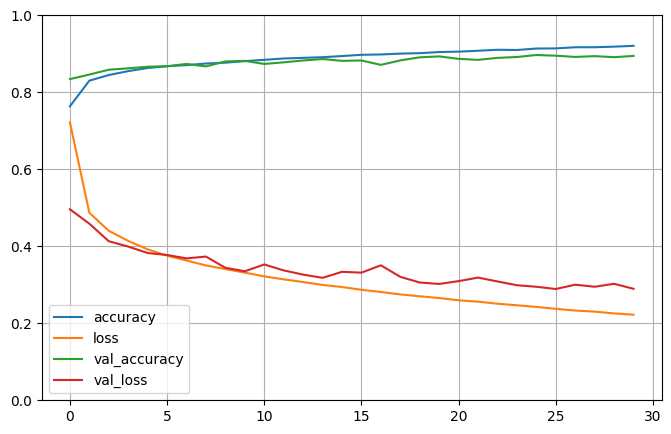

In [32]:
import pandas as pd
from matplotlib import pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [33]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8523 - loss: 62.3257


[62.32565689086914, 0.8522999882698059]

In [34]:
X_new = X_test[:3]
y_hat = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [35]:
y_hat

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [37]:
y_hat.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [39]:
y_pred = model.predict(X_new)
y_pred = y_pred.argmax(axis=-1)
np.array(class_names)[y_pred]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [40]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [43]:
housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full)

In [44]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_valid_scaled = x_scaler.transform(X_valid)
X_test_scaled = x_scaler.transform(X_test)

In [49]:
X_train.shape

(11610, 8)

In [50]:
X_train.shape[1:]

(8,)

In [55]:
model_reg = keras.Sequential()
model_reg.add(keras.layers.Input(shape=X_train_scaled.shape[1:], name="input_layer"))
model_reg.add(keras.layers.Dense(units=100, activation="relu", name="layer_1"))
model_reg.add(keras.layers.Dense(units=50, activation="relu", name="layer_2"))
model_reg.add(keras.layers.Dense(units=1, activation=None, name="output_layer"))

In [56]:
model_reg.compile(loss="mse",optimizer="sgd",metrics=["mse"])

In [58]:
history = model_reg.fit(X_train_scaled,y_train, validation_data=[X_valid_scaled,y_valid],epochs=30)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4760 - mse: 0.4760 - val_loss: 0.4831 - val_mse: 0.4831
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4341 - mse: 0.4341 - val_loss: 0.4512 - val_mse: 0.4512
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4129 - mse: 0.4129 - val_loss: 0.4293 - val_mse: 0.4293
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3946 - mse: 0.3946 - val_loss: 0.4143 - val_mse: 0.4143
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3788 - mse: 0.3788 - val_loss: 0.4135 - val_mse: 0.4135
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3723 - mse: 0.3723 - val_loss: 0.3964 - val_mse: 0.3964
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3639 - mse: 0.3639 - val_loss: 0.4012 - val_mse: 0.4012
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3617 - mse: 0.3617 - val_loss: 0.3912 - val_mse: 0.3912
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - 

In [59]:
y_hat = model_reg.predict(X_test_scaled)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step


In [60]:
y_hat

array([[3.4693775],
       [2.8001328],
       [2.504539 ],
       ...,
       [2.0230281],
       [1.6676081],
       [2.7597222]], shape=(5160, 1), dtype=float32)

In [61]:
y_test

array([4.638, 3.087, 2.78 , ..., 2.194, 1.708, 3.5  ], shape=(5160,))

In [62]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_hat)

In [63]:
mse

0.3233166399618368

In [65]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_,hidden2])
output = keras.layers.Dense(1, activation=None)(concat)
model_deep = keras.Model(inputs=[input_], outputs=[output])

In [71]:
model_deep.compile(loss="mse", metrics=["mse"], optimizer="adam")

In [72]:
history = model_deep.fit(X_train_scaled,y_train,validation_data=[X_valid_scaled,y_valid],epochs=30)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3857 - mse: 0.3857 - val_loss: 0.3578 - val_mse: 0.3578
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3615 - mse: 0.3615 - val_loss: 0.3373 - val_mse: 0.3373
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3220 - mse: 0.3220 - val_loss: 0.3167 - val_mse: 0.3167
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2978 - mse: 0.2978 - val_loss: 0.3056 - val_mse: 0.3056
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2799 - mse: 0.2799 - val_loss: 0.3078 - val_mse: 0.3078
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2737 - mse: 0.2737 - val_loss: 0.3103 - val_mse: 0.3103
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2711 - mse: 0.2711 - val_loss: 0.3004 - val_mse: 0.3004
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2705 - mse: 0.2705 - val_loss: 0.3250 - val_mse: 0.3250
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo